In [1]:
# Automatically locate the project's root directory
from crispdm.common.path_service_common import find_project_root

# Data manipulation and analysis using DataFrames
import pandas as pd

# Statistical data visualization built on top of matplotlib
import seaborn as sns

# Parsing and handling JSON data structures
import json

# Creating static, animated, and interactive visualizations
import matplotlib.pyplot as plt

# Numerical computing and support for large, multi-dimensional arrays
import numpy as np

# Fitting and working with statistical distributions (Normal, Skew-Normal, Gamma)
from scipy.stats import norm, skewnorm, gamma

# Object-oriented file system paths management
import pathlib

from IPython.display import display

# Reading and writing YAML configuration files
import yaml

In [2]:
# 1. Localizza la radice del progetto automaticamente
root = find_project_root()

# 2. Definisci il percorso verso la cartella di output (la base dei 'runs')
# l'ultima esecuzione o una specifica
run_id = "20260521_095921" # O l'ID che sto analizzando
base_run_dir = root / "outputs" / "runs" / "clustering" / "ms_sec_inc_pre" / run_id

# Definire il percorso di "base fase" per evitare hardcode in tutto il notebook
base_phase_path = base_run_dir / "phase2_data_understanding"

In [ ]:
##-------------- 2.1 ACQUISIZIONE DEI DATI (DATA ACQUISITION)

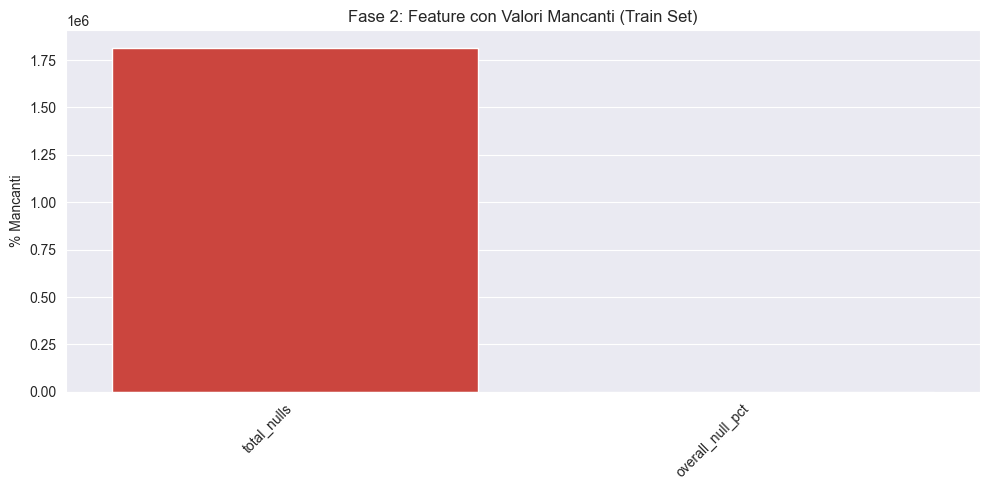

RELAZIONE FASE 2: UNDERSTANDING STATISTICO E SALUTE DEI DATI
1. Qualità dei dati (Missing Values): Trovate 2 feature con dati mancanti da imputare in Fase 3.
2. Data Drift tra Train e Test:
   -> ECCELLENTE: Nessun drift statistico rilevato. I set di dati sono perfettamente allineati.


In [4]:
# =============================================================================
# DEFINIZIONE PERCORSO FASE
# =============================================================================


# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================
# Selezioniamo i file più critici per la comprensione statistica
path_completeness = base_phase_path / "2.3.missing_data_profiling.completeness_report.train.json"
path_drift = base_phase_path / "2.3.statistical_health.data_drift.json"
path_stats = base_phase_path / "2.2.descriptive_statistics.basic_stats.train.json"

with open(path_completeness, 'r', encoding='utf-8') as f:
    completeness_data = json.load(f)

with open(path_drift, 'r', encoding='utf-8') as f:
    drift_data = json.load(f)

with open(path_stats, 'r', encoding='utf-8') as f:
    stats_data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Estraiamo le metriche di missing values per le colonne problematiche (>0%)
missing_threshold = 0.0
cols_with_missing = {k: v for k, v in completeness_data.items() if isinstance(v, (int, float)) and v > missing_threshold}

# Analizziamo il drift: verifichiamo se ci sono feature con p-value < 0.05 (distribuzioni diverse tra train e test)
drift_alerts = []
if "features" in drift_data:
    for feature, metrics in drift_data["features"].items():
        if metrics.get("p_value", 1.0) < 0.05:
            drift_alerts.append(feature)

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica
# =============================================================================
if cols_with_missing:
    plt.figure(figsize=(10, 5))

    # Salviamo le chiavi e i valori in variabili per mantenere il codice pulito
    x_labels = list(cols_with_missing.keys())
    y_values = list(cols_with_missing.values())

    sns.barplot(
        x=x_labels,
        y=y_values,
        hue=x_labels,          # <--- Correzione: assegniamo la x al parametro hue
        palette="Reds_r",
        legend=False           # <--- Correzione: nascondiamo la legenda ridondante
    )

    plt.title("Fase 2: Feature con Valori Mancanti (Train Set)")
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("% Mancanti")
    plt.tight_layout()
    plt.show()
else:
    print("Grafico omesso: Nessun valore mancante significativo rilevato.")

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================
print("=========================================================================")
print("RELAZIONE FASE 2: UNDERSTANDING STATISTICO E SALUTE DEI DATI")
print("=========================================================================")
print(f"1. Qualità dei dati (Missing Values): Trovate {len(cols_with_missing)} feature con dati mancanti da imputare in Fase 3.")
print(f"2. Data Drift tra Train e Test:")
if not drift_alerts:
    print("   -> ECCELLENTE: Nessun drift statistico rilevato. I set di dati sono perfettamente allineati.")
else:
    print(f"   -> ATTENZIONE: Rilevato drift nelle feature {drift_alerts}. Monitorare in fase di modellazione.")
print("=========================================================================")

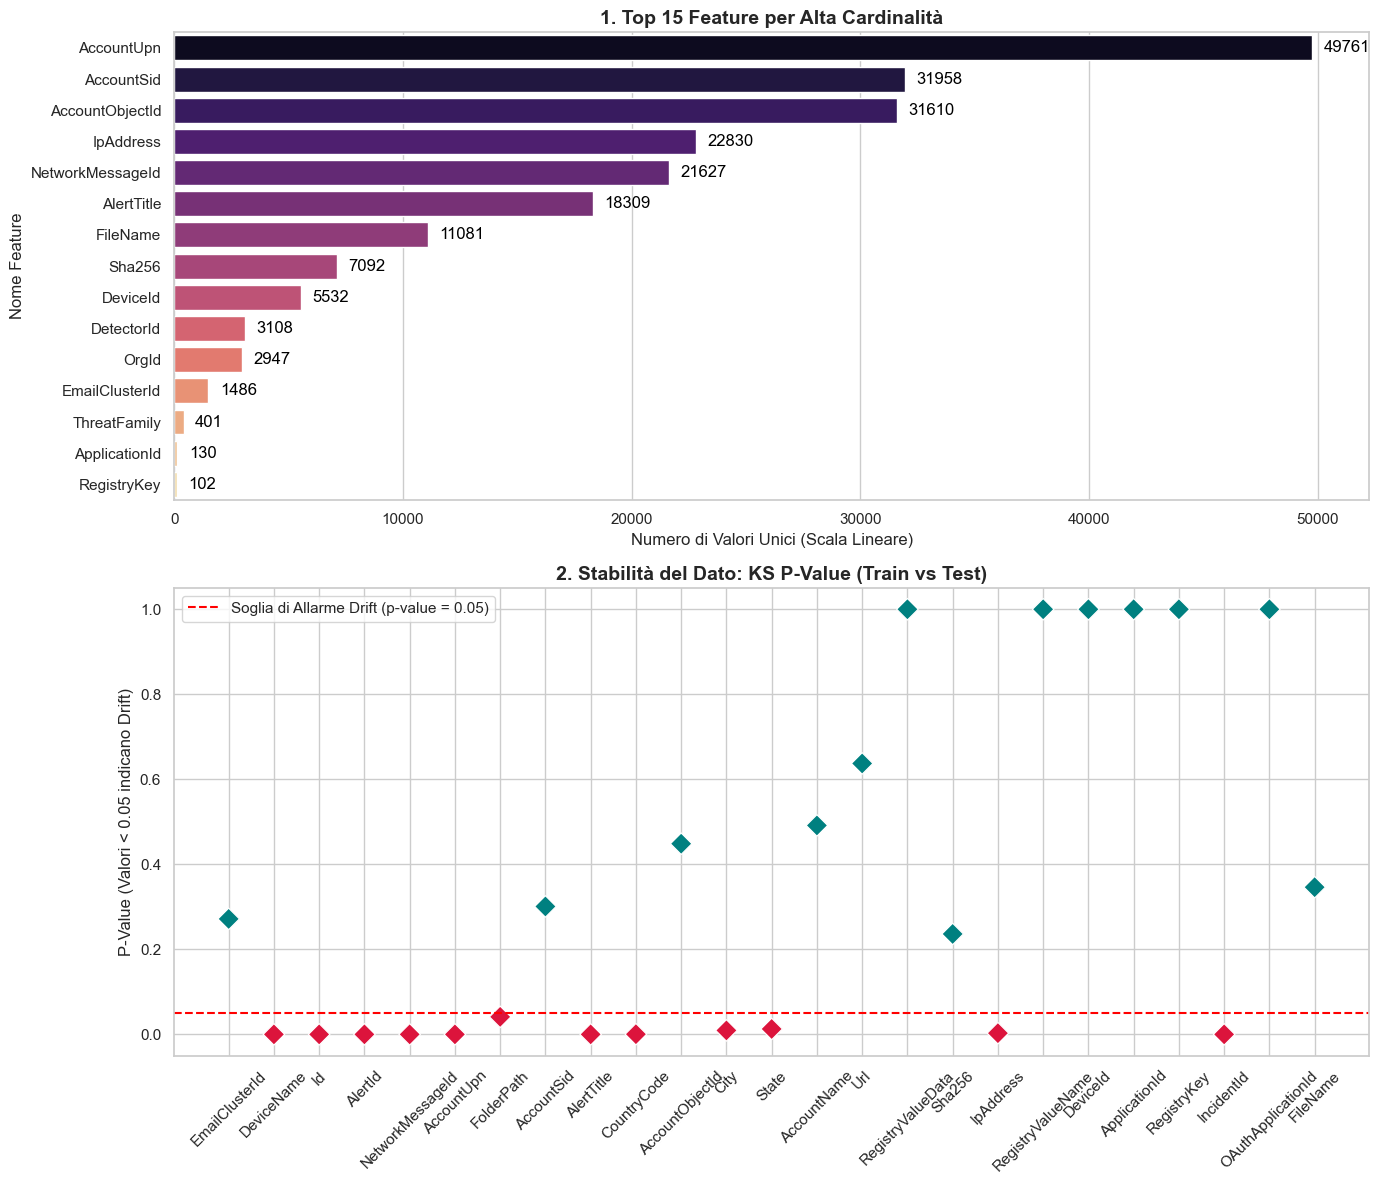

RELAZIONE FASE 2: ANALISI METADATI E SALUTE STRUTTURALE

1. Rischio Cardinalità:
   - La feature con la cardinalità più estrema è 'AccountUpn' con 49761 valori unici.
   - AZIONE RICHIESTA: Questa feature dominerà lo spazio delle distanze nel clustering se codificata in One-Hot.
     Necessario rimuoverla, raggrupparla (es. per dominî), o applicare Frequency Encoding nella Fase 3.

2. Verifica Data Drift (Kolmogorov-Smirnov Test):
   - Feature analizzate: 31
   - Feature che presentano uno shift statistico (Drift Flag = True): 14
   - ATTENZIONE: Le feature come ['DeviceName', 'Id', 'AlertId']... hanno subito una variazione di distribuzione.
     Il modello addestrato sul Train potrebbe avere prestazioni leggermente diverse sul Test per via di queste discrepanze temporali/strutturali.


In [7]:
# =============================================================================
# 1. FASE DI INPUT: Caricamento dei file JSON reali
# =============================================================================
path_cardinality = base_phase_path / "2.2.categorical_analysis.cardinality_profiling.train.json"
path_drift = base_phase_path / "2.3.statistical_health.data_drift.json"

with open(path_cardinality, 'r', encoding='utf-8') as f:
    cardinality_data = json.load(f)

with open(path_drift, 'r', encoding='utf-8') as f:
    drift_data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Estrazione Dinamica (Senza Hardcode)
# =============================================================================

# --- A. Estrazione della Cardinalità ---
# Navighiamo attraverso i gruppi (low, medium, high) e uniamo i risultati
cardinality_dict = {}
for category_level, columns_list in cardinality_data.items():
    for col_info in columns_list:
        col_name = col_info.get("column")
        n_unique = col_info.get("n_unique", 0)
        cardinality_dict[col_name] = n_unique

# Ordiniamo in modo decrescente e prendiamo le prime 15 feature per il grafico
top_cardinality = dict(sorted(cardinality_dict.items(), key=lambda item: item[1], reverse=True)[:15])

# --- B. Estrazione del Data Drift ---
# Il JSON è una lista di dizionari. Estraiamo il p-value del test di Kolmogorov-Smirnov (ks_pvalue)
drift_pvalues = {}
drift_flags = {}

for feature_info in drift_data:
    col_name = feature_info.get("column")
    # Alcuni ks_pvalue potrebbero essere nulli se il test fallisce, usiamo 1.0 come fallback sicuro
    p_val = feature_info.get("ks_pvalue")
    p_val = float(p_val) if p_val is not None else 1.0

    drift_pvalues[col_name] = p_val
    drift_flags[col_name] = feature_info.get("drift_flag", False)

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica
# =============================================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# --- Grafico 1: Profilazione della Cardinalità ---
x_labels_card = list(top_cardinality.keys())
y_values_card = list(top_cardinality.values())

sns.barplot(
    x=y_values_card,
    y=x_labels_card,
    hue=x_labels_card,
    palette="magma",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("1. Top 15 Feature per Alta Cardinalità", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Numero di Valori Unici (Scala Lineare)")
axes[0].set_ylabel("Nome Feature")

# Aggiungiamo i valori testuali alla fine di ogni barra per chiarezza
for i, v in enumerate(y_values_card):
    axes[0].text(v + (max(y_values_card)*0.01), i, str(v), color='black', va='center')

# --- Grafico 2: Stabilità del Dato (Data Drift P-Values) ---
# Selezioniamo solo le prime 25 feature per evitare sovraffollamento sull'asse X
x_labels_drift = list(drift_pvalues.keys())[:25]
y_values_drift = [drift_pvalues[k] for k in x_labels_drift]
colors = ["crimson" if drift_flags[k] else "teal" for k in x_labels_drift]

sns.scatterplot(
    x=x_labels_drift,
    y=y_values_drift,
    hue=x_labels_drift,
    palette=colors,
    s=120,
    marker="D",
    legend=False,
    ax=axes[1]
)

axes[1].axhline(0.05, color='red', linestyle='--', label="Soglia di Allarme Drift (p-value = 0.05)")
axes[1].set_title("2. Stabilità del Dato: KS P-Value (Train vs Test)", fontsize=14, fontweight='bold')
axes[1].set_ylabel("P-Value (Valori < 0.05 indicano Drift)")
axes[1].set_ylim(-0.05, 1.05)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================
print("=========================================================================")
print("RELAZIONE FASE 2: ANALISI METADATI E SALUTE STRUTTURALE")
print("=========================================================================")

# Estrazione dinamica degli insight per la stampa
max_card_col = list(top_cardinality.keys())[0]
max_card_val = top_cardinality[max_card_col]

drifted_cols = [col for col, flag in drift_flags.items() if flag]

print("\n1. Rischio Cardinalità:")
print(f"   - La feature con la cardinalità più estrema è '{max_card_col}' con {max_card_val} valori unici.")
if max_card_val > 1000:
    print("   - AZIONE RICHIESTA: Questa feature dominerà lo spazio delle distanze nel clustering se codificata in One-Hot.")
    print("     Necessario rimuoverla, raggrupparla (es. per dominî), o applicare Frequency Encoding nella Fase 3.")

print("\n2. Verifica Data Drift (Kolmogorov-Smirnov Test):")
print(f"   - Feature analizzate: {len(drift_pvalues)}")
print(f"   - Feature che presentano uno shift statistico (Drift Flag = True): {len(drifted_cols)}")

if len(drifted_cols) > 0:
    print(f"   - ATTENZIONE: Le feature come {drifted_cols[:3]}... hanno subito una variazione di distribuzione.")
    print("     Il modello addestrato sul Train potrebbe avere prestazioni leggermente diverse sul Test per via di queste discrepanze temporali/strutturali.")
else:
    print("   - STATO: Eccellente. Non è stato rilevato alcun drift significativo. Il dataset è stabile.")
print("=========================================================================")